Week 12 · Day 2 — Encoder Block
Why this matters

The encoder block is the core building unit of the Transformer.
It mixes self-attention (to relate tokens) with a feed-forward network (to transform features), stabilized by residual connections and layer normalization.

Theory Essentials

Self-Attention: lets each token “look” at others in the sequence.

Feed-Forward Network (FFN): position-wise MLP applied to each token embedding.

Residual Connections: add input back after sublayer → stabilizes training.

Layer Normalization: keeps activations well-scaled, improves convergence.

Structure:

Input → [LayerNorm → Multi-Head Self-Attention → Residual]

Output → [LayerNorm → Feed-Forward → Residual]

In [ ]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
np.random.seed(42)
torch.manual_seed(42)

# Simple Multi-Head Self-Attention (PyTorch built-in for now)
class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), 
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x):
        # x: [batch, seq_len, d_model]
        attn_out, _ = self.attn(x, x, x)  
        x = self.norm1(x + attn_out)       # residual + norm
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)         # residual + norm
        return x

# Example run
seq_len, d_model, num_heads, d_ff = 10, 16, 2, 64 # dff is the feed-forward hidden size
x = torch.rand(2, seq_len, d_model)  # batch=2
encoder_block = SelfAttentionBlock(d_model, num_heads, d_ff)
out = encoder_block(x)
print("Input shape:", x.shape)
print("Output shape:", out.shape)


Input shape: torch.Size([2, 10, 16])
Output shape: torch.Size([2, 10, 16])


### 1. Dimensions

* **`seq_len = 10`** → the number of tokens in each sequence.
* **`d_model = 16`** → the dimensionality of each token’s embedding vector.
* **`num_heads = 2`** → how many attention “heads” you split that 16-dim vector into (so each head works on `16/2 = 8` dims).
* **`d_ff = 64`** → this is the **feed-forward hidden size** (the intermediate layer width).

---

### 2. What happens inside the block

1. **Multi-Head Self-Attention**

   ```python
   attn_out, _ = self.attn(x, x, x)
   ```

   * Input `x` → shape `[batch, seq_len, d_model]`.
   * Splits into multiple heads, computes self-attention, recombines.
   * Output shape stays `[batch, seq_len, d_model]`.

2. **Residual + LayerNorm**

   ```python
   x = self.norm1(x + attn_out)
   ```

   * Add input `x` back (residual connection).
   * Normalize so training is stable.

3. **Feed-Forward Network (FFN)**

   ```python
   self.ff = nn.Sequential(
       nn.Linear(d_model, d_ff),   # 16 → 64
       nn.ReLU(),
       nn.Linear(d_ff, d_model)    # 64 → 16
   )
   ```

   * This is a **2-layer MLP** applied to each token *independently*.
   * First layer expands (16 → 64).
   * ReLU nonlinearity.
   * Second layer shrinks back (64 → 16).
   * Why? The expansion (`d_ff`) gives the network more capacity to transform features before projecting back to the model dimension.

4. **Residual + LayerNorm (again)**

   ```python
   x = self.norm2(x + ff_out)
   ```

   * Adds the feed-forward output back to the input.
   * Normalizes again.

---

### 3. Why `d_ff`?

Think of it as a **bottleneck-expansion trick**:

* You start with `d_model` (the embedding size).
* Expand into a larger hidden layer (`d_ff`) where the network can do richer transformations.
* Project back down to `d_model` so dimensions stay consistent across layers.

Typical rule of thumb: `d_ff ≈ 4 * d_model`.
(e.g., in the original Transformer paper, `d_model=512`, `d_ff=2048`).

---

✅ So yes — your intuition was right: it’s like “neurons in a hidden layer.”
Here, `16 → 64 → 16` means each token vector is processed by a small MLP before being sent on.

The reason you see **`x, x, x`** is because multi-head attention takes **three different inputs**:

* **Queries (Q)**
* **Keys (K)**
* **Values (V)**

---

### Why 3 inputs?

Attention is a *lookup mechanism*:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

* **Q (query):** what we’re asking about.
* **K (keys):** what we compare against.
* **V (values):** what information we bring back.

---

### In **Self-Attention**

* Every token needs to look at *every other token* in the same sequence.
* That means **Q, K, V all come from the same `x`** (the embedding sequence).
* So we pass `x, x, x`.

---

### In **Cross-Attention**

(used in the Transformer **decoder**)

* Queries come from the decoder’s current hidden states.
* Keys and values come from the encoder’s outputs.
* So you’d see something like `attn_out, _ = self.attn(decoder_x, encoder_x, encoder_x)`.

---

✅ So:

* Passing `x, x, x` = **self-attention**.
* Passing different sources = **cross-attention**.

---

1) Core (10–15 min)
Task: Run the encoder block with different num_heads (e.g. 1, 4). Check if output shape stays the same.

In [2]:
for h in [1, 4]:
    block = SelfAttentionBlock(d_model=16, num_heads=h, d_ff=64)
    print(f"Heads={h}, Output shape:", block(x).shape)


Heads=1, Output shape: torch.Size([2, 10, 16])
Heads=4, Output shape: torch.Size([2, 10, 16])


2) Practice (10–15 min)
Task: Compare model outputs with vs without residual connections.

In [3]:
class NoResidualBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(attn_out)      # no residual
        ff_out = self.ff(x)
        x = self.norm2(ff_out)        # no residual
        return x

print("With residual:", encoder_block(x)[0,0,:5])
print("Without residual:", NoResidualBlock(16,2,64)(x)[0,0,:5])


With residual: tensor([ 0.8651,  0.9097, -0.2065,  0.3789, -0.3557], grad_fn=<SliceBackward0>)
Without residual: tensor([ 0.0958, -0.4527, -1.4068, -0.6984,  1.4661], grad_fn=<SliceBackward0>)


### 1. **What it does**

At each sub-layer (attention or feed-forward), instead of just taking the transformed output, we do:

$$
\text{output} = \text{LayerNorm}(x + f(x))
$$

* `x` = the original input to the sub-layer.
* `f(x)` = the transformed version (attention or feed-forward).
* Adding them = **residual/skip connection**.

---

### 2. **Why we add back `x`**

* If you didn’t add `x`, then at every layer you only propagate the **new transformed signal**.
* That risks **vanishing gradients** (hard to train deep networks).
* With residuals, the network can always “fall back” to the identity mapping (just pass the input through unchanged). This makes optimization much easier.

---

### 3. **Interpretation**

* Think of it like: *“I’ll keep the original representation, but I’ll also mix in some improved features from this layer.”*
* This lets the model **accumulate knowledge gradually** across many layers instead of overwriting at each step.

---

### 4. **Your example**

* **With residuals**: outputs look well-behaved (values are moderate, not exploding or collapsing).
* **Without residuals**: outputs can drift wildly (values are large, unstable).

  * That’s why your “Without residual” tensor had much stronger swings (–1.4, +1.4, etc.).

---

👉 Memory hook:
Residual = *shortcut highway* for information and gradients → “don’t lose what you already know, just refine it.”


3) Stretch (optional, 10–15 min)
Task: Visualize how one encoder block transforms token vectors.

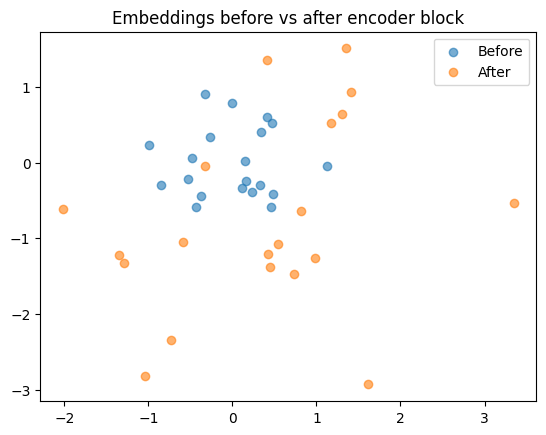

In [4]:
from sklearn.decomposition import PCA

before = x.detach().reshape(-1, d_model)
after = out.detach().reshape(-1, d_model)

pca = PCA(2)
coords_before = pca.fit_transform(before)
coords_after = pca.transform(after)

plt.scatter(coords_before[:,0], coords_before[:,1], label="Before", alpha=0.6)
plt.scatter(coords_after[:,0], coords_after[:,1], label="After", alpha=0.6)
plt.legend(); plt.title("Embeddings before vs after encoder block")
plt.show()


1. **Tokenization → Token vectors**

   * Each word (or subword) is mapped to a numeric **embedding vector** of size `d_model`.
   * Example: “dog” → `[0.12, -0.45, …, 0.88]` (length 16, 512, 768… depending on the model).

2. **Add positional encoding**

   * Because Transformers don’t know order by themselves.
   * So the final input to the encoder is:

     $$
     x = \text{token\_embedding} + \text{positional\_encoding}
     $$

3. **Pass through encoder block(s)**

   * **Self-attention:** lets each word look at every other word in the same sentence.

     * This reshapes the embedding space so “related” words become closer (e.g., “king” ↔ “queen”, or “dog” ↔ “puppy”).
   * **Feed-forward network:** applies further transformation on each token vector individually.
   * **Residuals + layer norm:** stabilize and keep original signal.

4. **Output of the encoder**

   * A new set of embeddings, one per token, but now *contextualized*.
   * E.g., “bank” in “river bank” and “bank account” will have different vectors after self-attention.

---

👉 In your code, you haven’t explicitly added **positional encodings** yet, so you’re only seeing the effect of attention + feed-forward.
But in real practice, yes — you always add them before the first encoder block.


Mini-Challenge (≤40 min)

Build a 2-Layer Encoder Stack.

Input: random sequence embeddings [batch, seq_len, d_model].

Stack two encoder blocks.

Visualize how the variance of token embeddings changes after each layer.

Acceptance Criteria:

Runs with arbitrary batch/seq length.

Output shape [batch, seq_len, d_model] preserved.

Plot: variance of embeddings across tokens at input, after 1st layer, after 2nd.

Shapes: torch.Size([3, 28, 32]) torch.Size([3, 28, 32]) torch.Size([3, 28, 32])
Variance across tokens — input: 1.1340 | after L1: 0.8094 | after L2: 0.8090


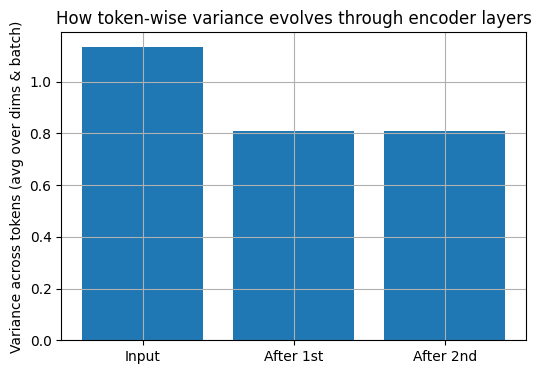

In [5]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
np.random.seed(42); torch.manual_seed(42)
plt.rcParams["figure.figsize"] = (6,4); plt.rcParams["axes.grid"] = True

# Positional encoding (sinusoidal)
def positional_encoding(seq_len, d_model, device=None):
    device = device or "cpu"
    pos = torch.arange(seq_len, device=device).unsqueeze(1)           # [seq_len, 1]
    i   = torch.arange(d_model, device=device).unsqueeze(0)           # [1, d_model]
    angle_rates = 1.0 / (10000 ** (2*(i//2) / d_model))
    angles = pos * angle_rates
    PE = torch.zeros(seq_len, d_model, device=device)
    PE[:, 0::2] = torch.sin(angles[:, 0::2])
    PE[:, 1::2] = torch.cos(angles[:, 1::2])
    return PE  # [seq_len, d_model]

# One encoder block (MHSA → add&norm → FFN → add&norm)
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)       # self-attention
        x = self.norm1(x + attn_out)           # residual + norm
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)             # residual + norm
        return x

# 2-layer encoder stack
class EncoderStack(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, n_layers=2):
        super().__init__()
        self.layers = nn.ModuleList([EncoderBlock(d_model, num_heads, d_ff) for _ in range(n_layers)])
    def forward(self, x):
        outs = [x]
        for layer in self.layers:
            x = layer(x)
            outs.append(x)
        return outs  # [input, after1, after2]

# ---- Config (works with arbitrary batch/seq) ----
batch, seq_len, d_model = 3, 28, 32
num_heads, d_ff = 4, 128
device = "cpu"

# Random embeddings + positional encoding
x = torch.randn(batch, seq_len, d_model, device=device)
pe = positional_encoding(seq_len, d_model, device=device)
x = x + pe.unsqueeze(0)  # add PE to every sequence in the batch

# Run through two layers
stack = EncoderStack(d_model, num_heads, d_ff, n_layers=2).to(device)
x0, x1, x2 = stack(x)  # tensors: [batch, seq_len, d_model]

# Shape check (acceptance criterion)
print("Shapes:", x0.shape, x1.shape, x2.shape)  # all should be [batch, seq_len, d_model]

# ---- Variance across tokens ----
# For each stage, compute variance over the token axis (seq_len), then average over features.
def token_variance(t):  # t: [B, T, D]
    # var across tokens → [B, D], then mean over D → [B], then mean over batch → scalar
    return t.var(dim=1).mean(dim=1).mean().item()

v0, v1, v2 = token_variance(x0), token_variance(x1), token_variance(x2)
print(f"Variance across tokens — input: {v0:.4f} | after L1: {v1:.4f} | after L2: {v2:.4f}")

# Plot
stages = ["Input", "After 1st", "After 2nd"]
vals = [v0, v1, v2]
plt.bar(stages, vals)
plt.ylabel("Variance across tokens (avg over dims & batch)")
plt.title("How token-wise variance evolves through encoder layers")
plt.show()


Notes / Key Takeaways

Encoder block = (Self-Attention + Feed-Forward) with residual + normalization.

Residuals preserve information and stabilize deep models.

LayerNorm applied before or after is a design choice (here: post-norm).

Each token embedding transformed independently in FFN but mixed in Attention.

Stacking blocks → deeper understanding of context.

Output shape stays [batch, seq_len, d_model].

Reflection

Why do we need both attention and feed-forward layers in each encoder block?

How do residual connections help prevent “vanishing representation” in deep models?

1. Why do we need both attention and feed-forward layers in each encoder block?

Attention layer: lets each token look at other tokens → captures relationships and context (e.g., “bank” near “river” vs “money”).

Feed-forward layer: applies a non-linear transformation to each token individually → enriches the representation, allowing more complex patterns.
Together, they combine global context (attention) with local feature transformation (FFN).

2. How do residual connections help prevent “vanishing representation” in deep models?

Without residuals, each layer overwrites the signal, and information can degrade as you stack more layers.

With residuals, the model always keeps a “shortcut” path:

output=x+f(x)

This preserves the original representation, ensures gradients flow backward more easily, and prevents the network from collapsing into useless outputs.

In practice, residuals let very deep Transformers (hundreds of layers) train stably.

👉 Memory hook:

Attention = “look around”, FFN = “think deeper”, Residuals = “don’t forget what you already knew.”